# **animove**
### Spatial Dynamics, Temporal Rhythms, and Biological Influences on Bobcat (*Lynx rufus*) Movement Near Black Rock Forest, New York

**By**: Zhean Robby Ganituen, Jaztin Jacob Jimenez, Reece Benedict Orense, Ashley Paulianna Reyes, and Matthew Fraser Sim

---

# **1. Abstract**
This study investigates the spatial, temporal, and biological factors influencing the movement behaviors of Bobcats (*Lynx rufus*) near Black Rock Forest, New York. Utilizing high-frequency GPS telemetry data and biological metadata collected between 2020 and 2026, we explore individual activity budgets, circadian rhythms, and territorial boundaries. By applying spatial mapping techniques (KDE) and temporal feature engineering, this exploratory data analysis aims to uncover how intrinsic biological traits (such as sex, mass, and life-stage) correlate with the varied movement patterns of this elusive carnivore.

**Dataset**: LaPoint, S. 2026. Data from: Study “Carnivore movements near Black Rock Forest New York” [part]. Movebank Data Repository.

**Paper**: Oliver, R.Y. et al. 2026. Interacting effects of human presence and landscape modification on birds and mammals. Science. 392, 6800 (May 2026), 879–884. https://doi.org/10.1126/science.adq3396.

---

# **2. Dataset Description**
The dataset utilized in this study, titled *"Carnivore movements near Black Rock Forest New York"*, was sourced from the Movebank Data Repository and contributed to the broader ecological research by Oliver et al. (2026). 

The raw, integrated dataset (`joined.csv`) was created by merging high-frequency GPS tracking data (the "pings") with the biographical capture metadata of the animals. Initially, this combined dataset contains **131,930 observations (rows)** and **49 variables (columns)**, tracking two distinct carnivore species: *Lynx rufus* (Bobcats) and *Pekania pennanti* (Fishers) between the years 2020 and 2026.

### Data Collection Method
The data was collected in the field via live-trapping and collaring as part of the Hudson Highlands Wildlife Connectivity Project. Researchers captured the bobcats (*Lynx rufus*) using Camtrip cage traps disguised with debris and landscape cloth, and baited with visual attractants and lures. Once trapped, the bobcats were sedated via a syringe pole with a mixture of Ketamine HCL and Xylazine HCL. While sedated, researchers monitored their vital signs, recorded their biological metrics (mass, sex, life-stage), and fitted them with "e-obs" brand GPS tracking collars (weighing 170g for males and 20g for females) before safely releasing them. These collars were programmed to automatically record the animal's exact spatial coordinates, speed, and ambient temperature, with data retrieved wirelessly via base stations.

### Implications of the Collection Method
This specific method of capture and automated telemetry introduces several critical implications and potential biases for our data insights:
1. **Sample Size vs. Observation Count:** While the automated collars generated a massive volume of observations (over 100,000 pings), the actual sample size of distinct individuals is extremely small ($n=7$ bobcats). Any behavioral trends discovered may not generalize to the entire *Lynx rufus* species but rather reflect the specific habits of this local population.
2. **Capture Bias:** The dataset only includes animals that were successfully lured into cage traps. It is highly probable that trap-shy individuals—which may inherently exhibit different behavioral, spatial, or territorial patterns—are entirely missing from this dataset. 
3. **Spatiotemporal Autocorrelation:** Because the data is collected continuously from the same individuals, the observations are not statistically independent. An animal's location at 2:00 PM is highly dependent on its location at 1:00 PM.
4. **Hardware Limitations:** GPS signals can be blocked by dense canopy cover, topography, or weather, occasionally resulting in missed fixes or inaccurate coordinate estimations (`eobs:horizontal-accuracy-estimate`), which necessitated rigorous data cleaning prior to analysis.

Because our research question focuses strictly on an intra-species analysis of Bobcat behavior, we will be filtering the dataset to isolate the *Lynx rufus* records. To answer our specific questions regarding territoriality, daily rhythms, and biological impacts, we will focus on the following key variables, which can be grouped into four distinct categories:

### Identifiers
* **`animal-id`**: The unique identifier assigned to a specific animal (e.g., `LYRU_0001`). This allows us to track individual behavior and group data points by specific bobcats.
* **`animal-taxon`**: The scientific name of the species (*Lynx rufus*). Used primarily to filter the initial dataset.

### Biological Attributes
* **`animal-sex`**: The biological sex of the bobcat (`m` for male, `f` for female).
* **`animal-life-stage`**: The developmental stage of the bobcat at the time of collar deployment (e.g., `adult`, `subadult`, `juvenile`).
* **`animal-mass`**: The weight of the bobcat when it was captured, recorded in grams. 

### Spatial and Movement Metrics
* **`location-long`** & **`location-lat`**: The exact geographical coordinates (longitude and latitude) of the animal at the time of the GPS recording. Crucial for mapping territorial boundaries and home ranges.
* **`ground-speed`**: The estimated speed the bobcat was moving at the time of the recording (in meters per second), serving as our primary proxy for "activity level."

### Temporal Metrics
* **`timestamp`**: The exact UTC date and time the GPS location was recorded. During our preprocessing phase, this will be transformed to extract local time zones (`timestamp-local`), specific hours of the day (`hour-local`), and seasonal data to analyze daily and yearly behavioral rhythms.

## **Definition of Terms**
To ensure clarity throughout our exploratory data analysis, we define the key ecological and data science terms used in this study below:

- **Home Range / Territorial Boundary**: The spatial area in which an individual bobcat lives, travels, and hunts. In this dataset, it is mapped using longitudinal and latitudinal GPS coordinates.
- **Kernel Density Estimation (KDE)**: A spatial data visualization technique used to create a continuous "heatmap" of an animal's location points. This allows us to smoothly identify dense core territories and visualize where different animals' ranges naturally overlap.
- **Activity Level / Budget**: The proportion of time an animal spends actively moving versus resting. In this study, we infer activity levels primarily through the `ground-speed` metric.
- **Biological Attributes**: The intrinsic physical or demographic characteristics of an individual animal—specifically its sex, mass (in grams), and life-stage (juvenile, subadult, adult)—which may influence its spatial and temporal behavior.
- **Diel / Temporal Rhythm**: The synchronized, daily behavioral schedule of an animal occurring over a 24-hour cycle (e.g., shifting between periods of active travel and resting).

## **Project Plan and Data Handling Strategy**
To effectively answer our general research question regarding Bobcat spatial and temporal dynamics, our plan for handling this dataset involves four main phases:

1. **Target Filtering:** The initial dataset contains a severe class imbalance (~88% Bobcats and ~12% Fishers, with the Fisher data heavily skewed toward a single individual). To ensure statistical validity and prevent generalization errors in future modeling, our first step is to filter the dataset to strictly isolate the *Lynx rufus* (Bobcat) records.
2. **Data Cleaning (`janitor.py`):** We will utilize custom cleaning modules to sanitize the tracking data. This includes removing invalid GPS fixes (e.g., failed 3D satellite connections), dropping telemetry points recorded outside the official collar deployment dates, and filtering out any coordinates flagged as system or manual outliers.
3. **Feature Engineering (`transformer.py`):** Because our temporal analysis relies heavily on daily schedules, we will engineer new features from the raw data. We will convert the default UTC timestamps into the local timezone (America/New_York) and extract specific attributes such as the `hour-local` and `season`. 
4. **Dimensionality Reduction (`reducer.py`):** The raw dataset contains numerous columns dedicated strictly to the physical tracking hardware (e.g., e-obs battery voltages, transmission checksums, and sensor statuses). We will drop these irrelevant diagnostic columns to streamline the dataset, retaining only the spatial, temporal, and biological variables necessary for our Exploratory Data Analysis (EDA).

## **0 setup**

Let's first import the Python libraries needed for the project and define some filenames which will be used throughout the dataset.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

# Directories
DIR_DATA = "../data/"
DIR_RAW_DATA = DIR_DATA + "raw/"
DIR_PROC_DATA = DIR_DATA + "processed/"

# Output Filenames
OUT_JOINED_DATASET = DIR_RAW_DATA + "joined.csv"
OUT_PPROC_DATASET = DIR_PROC_DATA + "preprocessed.csv"

# DataFrames global variables
MAIN_DF = ()
REF_DF = ()
JOIN_DF = ()
PPROC_DF = ()

### **0.1 dataset loading**

Now, let's load the two raw datasets as a pandas `DataFrame`.

In [2]:
MAIN_DF = pd.read_csv(DIR_RAW_DATA + "main.csv")
REF_DF = pd.read_csv(DIR_RAW_DATA + "reference.csv")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_20072\795800667.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  MAIN_DF = pd.read_csv(DIR_RAW_DATA + "main.csv")


### **0.2 joining**

Before doing any cleaning, let's first join the two. 

To get an idea of what the dataset looks like. Let's first print the columns and information from each dataframe. From this, we can come up with a methodology for joining the two.

In [3]:
print("\t========== Main DataFrame ========== ")
print(MAIN_DF.info())

	========== Main DataFrame ========== 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   event-id                           131930 non-null  int64  
 1   visible                            131930 non-null  bool   
 2   timestamp                          131930 non-null  object 
 3   location-long                      126483 non-null  float64
 4   location-lat                       126483 non-null  float64
 5   data-decoding-software             131930 non-null  int64  
 6   eobs:battery-voltage               131930 non-null  int64  
 7   eobs:fix-battery-voltage           131930 non-null  int64  
 8   eobs:horizontal-accuracy-estimate  126483 non-null  float64
 9   eobs:key-bin-checksum              131930 non-null  int64  
 10  eobs:speed-accuracy-estimate       126483 non-null  float64
 11  

In [4]:
print("\t========== Reference DataFrame ========== ")
print(REF_DF.info())

	========== Reference DataFrame ========== 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tag-id                 9 non-null      int64  
 1   animal-id              9 non-null      object 
 2   animal-taxon           9 non-null      object 
 3   deploy-on-date         9 non-null      object 
 4   deploy-off-date        8 non-null      object 
 5   animal-life-stage      9 non-null      object 
 6   animal-mass            9 non-null      float64
 7   animal-offspring       1 non-null      object 
 8   animal-parents         2 non-null      object 
 9   animal-sex             9 non-null      object 
 10  animal-siblings        2 non-null      object 
 11  attachment-body-part   9 non-null      object 
 12  attachment-type        9 non-null      object 
 13  deploy-on-latitude     1 non-null      float64
 14  deploy-on-longitud

From here, the column `individual-local-identifier` (`ili`) from `MAIN_DF` and `animal-id` from `REF_DF` seem to be related to each other. Let's verify this claim by checking that the set of possible values for each column is the same.

In [5]:
unique_ili_id = set(MAIN_DF["individual-local-identifier"].unique())
unique_animal_id = set(REF_DF["animal-id"].unique())

print("\t========== Is ili and animal-id a potential join key? ==========")
if unique_ili_id == unique_animal_id:
    print("YES")
    print(unique_ili_id)
else:
    print("NO")

	========== Is ili and animal-id a potential join key? ==========
YES
{'LYRU_0005', 'LYRU_0008', 'LYRU_0003', 'PEPE_0001', 'PEPE_0002', 'LYRU_0006', 'LYRU_0002', 'LYRU_0001', 'LYRU_0004'}


Now that we know that `ili` and `animal-id` is the join key. We will now join `MAIN_DF` and `REF_DF` to construct `JOIN_DF`. But let's first rename `ili` to `animal-id`. Then, we'll call `pd.merge` on the join key (which is now `animal-id`).

In [6]:
MAIN_DF = MAIN_DF.rename(columns={"individual-local-identifier": "animal-id"})
JOIN_DF = pd.merge(MAIN_DF, REF_DF, on="animal-id")

Now let's see the columns and information of the dataset after performing the join. Let's ensure that information of the two datasets were kept after merging by performing some tests.

In [7]:
print("\t========== Joined DataFrame ========== ")
print("(Running tests...)")
print(
    "=== The total number of columns must be len(MAIN_DF.columns) + len(REF_DF.columns) - 1"
)
assert len(MAIN_DF.columns) + len(REF_DF.columns) - 1 == len(JOIN_DF.columns)

print("=== The total number of entries must be the max(len(MAIN_DF), len(REF_DF))")
assert max(len(MAIN_DF), len(REF_DF)) == len(JOIN_DF)

print()
print("(Saving joined dataset...)")
JOIN_DF.to_csv(OUT_JOINED_DATASET, index=False)

print()
print("=== JOIN_DF info")
print(JOIN_DF.info())

	========== Joined DataFrame ========== 
(Running tests...)
=== The total number of columns must be len(MAIN_DF.columns) + len(REF_DF.columns) - 1
=== The total number of entries must be the max(len(MAIN_DF), len(REF_DF))

(Saving joined dataset...)

=== JOIN_DF info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 49 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   event-id                           131930 non-null  int64  
 1   visible                            131930 non-null  bool   
 2   timestamp                          131930 non-null  object 
 3   location-long                      126483 non-null  float64
 4   location-lat                       126483 non-null  float64
 5   data-decoding-software             131930 non-null  int64  
 6   eobs:battery-voltage               131930 non-null  int64  
 7   eobs:fix-battery-voltage       

## **# 3. Dataset Preprocessing**

Now that we have the joined dataset, we can proceed with the cleaning phase.


Three source files are important for this section:
- `janitor` defines functions and a shared interface for **cleaning**.
- `transformer` defines functions and a shared interface for **transforming** data into more useful formats.
- `reducer` defines variables and functions for **dimensionality reduction** (removing unnecessary columns).

In [8]:
import janitor
import transformer
import reducer

preprocess_step_df = JOIN_DF

### 3.1 Filtering Target Species (*Lynx rufus*)
Upon initial inspection, the dataset contains two species: *Lynx rufus* (Bobcats, ~88% of data) and *Pekania pennanti* (Fishers, ~12% of data). Furthermore, the Fisher data is heavily skewed toward a single individual. To prevent severe class imbalance and lack of generalization in future modeling (MCO2), we filter the dataset to strictly isolate the Bobcat records.

In [ ]:
# Filter dataset to only include Bobcats (Lynx rufus)
from src.janitor import clean_runner, keep_only_bobcats

preprocess_step_df, report = clean_runner(preprocess_step_df, keep_only_bobcats)
report.out()

<p style="color: red;">ADD EXPLANATION.</p>

In [9]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_fishers
)
report.out()

	========== Janitor ========== 
		Rows before		: 131930
		Rows remaining		: 116256
		Rows removed		: 15674
		Examples (max 3)	:                                                                               112677                                             112678                                             112679
event-id                                                                 26403030653                                        26403030670                                        26403030672
visible                                                                         True                                               True                                               True
timestamp                                                    2023-03-21 16:00:53.000                            2023-03-21 17:01:11.000                            2023-03-21 18:00:23.000
location-long                                                             -74.048125                                        

<p style="color: red;">ADD EXPLANATION.</p>

In [10]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_bad_gps
)
report.out()

	========== Janitor ========== 
		Rows before		: 116256
		Rows remaining		: 112312
		Rows removed		: 3944
		Examples (max 3)	:                                                                                  25                                                 26                                                 134
event-id                                                                 14056446662                                        14056446663                                        14056446771
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 22:40:15.000                            2020-02-12 22:40:16.000                            2020-02-13 13:36:08.000
location-long                                                                    NaN                                         

<p style="color: red;">ADD EXPLANATION.</p>

In [11]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_with_markers
)
report.out()

	========== Janitor ========== 
		Rows before		: 112312
		Rows remaining		: 112307
		Rows removed		: 5
		Examples (max 3)	:                                                                                36976                                              36977                                              36978
event-id                                                                 18681223130                                        18681223131                                        18681223132
visible                                                                        False                                              False                                              False
timestamp                                                    2021-04-28 16:38:21.000                            2021-04-28 16:40:10.000                            2021-04-28 16:42:10.000
location-long                                                             -74.024605                                         -74

<p style="color: red;">ADD EXPLANATION.</p>

In [12]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_bad_fix
)
report.out()

	========== Janitor ========== 
		Rows before		: 112307
		Rows remaining		: 112232
		Rows removed		: 75
		Examples (max 3)	:                                                                                84338                                              84925                                              84940
event-id                                                                 47041856868                                        47041856869                                        47041856870
visible                                                                         True                                               True                                               True
timestamp                                                    2023-04-27 13:01:20.000                            2023-04-30 21:01:20.000                            2023-05-01 04:29:19.000
location-long                                                             -74.092102                                         -7

### 3.3 Standard Data Cleaning: Missing Values and Duplicates
Standard machine learning practices require the removal of duplicate records and missing values (NaNs). Because our exploratory data analysis relies heavily on mapping territories and calculating activity budgets, any rows missing critical spatial coordinates (`location-lat`, `location-long`) or movement data (`ground-speed`) will cause graphing errors and model failures. We drop these invalid rows here.

In [ ]:
# Drop duplicates and rows missing critical spatial/speed data
from src.janitor import drop_dupes_and_nulls

preprocess_step_df, report = clean_runner(preprocess_step_df, drop_dupes_and_nulls)
report.out()

<p style="color: red;">ADD EXPLANATION.</p>

In [13]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df, func=transformer.add_utc_time, source_cols=["timestamp"]
)
report.out()

	========== Transformer ========== 
		Added columns	: ['timestamp-utc']
		Before (max 3)	:
                                 0                        1                        2
event-id               14056446637              14056446638              14056446639
timestamp  2020-02-12 16:02:53.000  2020-02-12 16:02:54.000  2020-02-12 16:02:55.000
		After  (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp        2020-02-12 16:02:53.000    2020-02-12 16:02:54.000    2020-02-12 16:02:55.000
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00


<p style="color: red;">ADD EXPLANATION.</p>

In [14]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_outside_deploy
)
report.out()

	========== Janitor ========== 
		Rows before		: 112232
		Rows remaining		: 112232
		Rows removed		: 0
		Examples (max 3)	: Empty DataFrame
Columns: []
Index: [event-id, visible, timestamp, location-long, location-lat, data-decoding-software, eobs:battery-voltage, eobs:fix-battery-voltage, eobs:horizontal-accuracy-estimate, eobs:key-bin-checksum, eobs:speed-accuracy-estimate, eobs:start-timestamp, eobs:status, eobs:temperature, eobs:type-of-fix, eobs:used-time-to-get-fix, ground-speed, heading, height-above-ellipsoid, import-marked-outlier, manually-marked-outlier, sensor-type, individual-taxon-canonical-name, tag-local-identifier, animal-id, study-name, tag-id, animal-taxon, deploy-on-date, deploy-off-date, animal-life-stage, animal-mass, animal-offspring, animal-parents, animal-sex, animal-siblings, attachment-body-part, attachment-type, deploy-on-latitude, deploy-on-longitude, deploy-on-person, deployment-comments, deployment-id, manipulation-type, tag-beacon-frequency, tag-manufact

<p style="color: red;">ADD EXPLANATION.</p>

In [15]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_dup_sessions
)
report.out()

	========== Janitor ========== 
		Rows before		: 112232
		Rows remaining		: 94490
		Rows removed		: 17742
		Examples (max 3)	:                                                                                    0                                                  1                                                  3
event-id                                                                 14056446637                                        14056446638                                        14056446640
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 17:00:25.000
location-long                                                             -74.059272                                         

<p style="color: red;">ADD EXPLANATION.</p>

In [16]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df,
    func=transformer.add_local_features,
    source_cols=["timestamp-utc"],
)

report.out()

	========== Transformer ========== 
		Added columns	: ['timestamp-local', 'hour-local', 'date-local', 'month-local', 'season']
		Before (max 3)	:
                                       0                          1                          2
event-id                     14078351206                47041858690                19885952950
timestamp-utc  2020-02-27 04:00:25+00:00  2026-03-08 06:50:23+00:00  2021-08-31 08:00:23+00:00
		After  (max 3)	:
                                         0                          1                          2
event-id                       14078351206                47041858690                19885952950
timestamp-utc    2020-02-27 04:00:25+00:00  2026-03-08 06:50:23+00:00  2021-08-31 08:00:23+00:00
timestamp-local  2020-02-26 23:00:25-05:00  2026-03-08 01:50:23-05:00  2021-08-31 04:00:23-04:00
hour-local                              23                          1                          4
date-local                      2020-02-26                 2026-0

<p style="color: red;">ADD EXPLANATION.</p>

In [17]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df,
    func=transformer.add_movement,
    source_cols=["timestamp-utc", "location-lat", "location-long", "ground-speed"],
)

report.out()

	========== Transformer ========== 
		Added columns	: ['dt-seconds', 'step-meters', 'derived-speed-ms']
		Before (max 3)	:
                                   35052                      59139                      62773
event-id                     14056446639                14056446642                14056446645
timestamp-utc  2020-02-12 16:02:55+00:00  2020-02-12 17:00:27+00:00  2020-02-12 18:00:49+00:00
location-lat                   41.380708                   41.38084                  41.380899
location-long                 -74.059251                 -74.059188                 -74.059135
ground-speed                        0.09                       0.04                       0.24
		After  (max 3)	:
                                          0                          1                          2
event-id                        14056446639                14056446642                14056446645
timestamp-utc     2020-02-12 16:02:55+00:00  2020-02-12 17:00:27+00:00  2020-02-12 18:00:49+

### 3.6 Dimensionality Reduction
The raw dataset contains numerous columns dedicated to tracking hardware diagnostics (e.g., e-obs battery voltages, sensor statuses). To streamline our dataset for analysis, we use our `reducer.py` module to drop these irrelevant columns. We ensure that we retain our engineered temporal features (`hour-local`, `season`), our spatial features (`location-long`, `location-lat`), and critically, our biological attributes (`animal-sex`, `animal-mass`, `animal-life-stage`) to answer our EDA questions.

In [ ]:
from src.reducer import reduce

# Updated columns to retain spatial, temporal, and biological data
COLS_TO_KEEP = [
    'animal-id',
    'timestamp-local',
    'hour-local',
    'season',
    'location-long',
    'location-lat',
    'ground-speed',
    'animal-sex',         
    'animal-mass',        
    'animal-life-stage'   
]

preprocess_step_df = reduce(preprocess_step_df, COLS_TO_KEEP)

print(f"Columns remaining: {len(preprocess_step_df.columns)}")
print(preprocess_step_df.head())

In [19]:
preprocess_step_df = reducer.reduce(df=preprocess_step_df, cols=keep_cols)

assert len(preprocess_step_df.columns) == len(keep_cols)

Now that we have performed all cleaning steps, let's store the final result in `PPROC_DF` and check its information.

In [20]:
PPROC_DF = preprocess_step_df

print("\t========== Preprocessed DataFrame ========== ")
print(PPROC_DF.info())

PPROC_DF.to_csv(OUT_PPROC_DATASET)

	========== Preprocessed DataFrame ========== 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94490 entries, 0 to 94489
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype                           
---  ------                             --------------  -----                           
 0   event-id                           94490 non-null  int64                           
 1   animal-id                          94490 non-null  object                          
 2   individual-taxon-canonical-name    94490 non-null  object                          
 3   timestamp                          94490 non-null  object                          
 4   timestamp-utc                      94490 non-null  datetime64[ns, UTC]             
 5   timestamp-local                    94490 non-null  datetime64[ns, America/New_York]
 6   hour-local                         94490 non-null  int32                           
 7   date-local                         944

## **2 Exploratory Data Analysis**

## **Setup and data overview**

The preprocessed dataset is already in memory as `PPROC_DF`. Here we import the plotting libraries, set one visual theme for every figure below, and take a quick look at how much data each bobcat contributes before we start plotting.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Plot off a copy so nothing here changes the preprocessed frame.
EDA_DF = PPROC_DF.copy()

Before plotting anything, it helps to see what we are working with. The table below shows how many fixes each bobcat contributed, which seasons it was tracked through, and how often the collar took a reading. Those numbers decide how much the pooled averages can really be trusted.

In [ ]:
# How much each bobcat contributes, how many seasons it covers, and its date span.
overview = (
    EDA_DF.groupby("animal-id")
    .agg(
        n_fixes=("event-id", "size"),
        seasons=("season", "nunique"),
        first_day=("date-local", "min"),
        last_day=("date-local", "max"),
    )
    .sort_values("n_fixes", ascending=False)
)
overview["share_%"] = (100 * overview["n_fixes"] / len(EDA_DF)).round(1)
print(overview)

# How often the collar recorded a fix (seconds between consecutive fixes).
print("\nSampling interval, dt-seconds:")
print(EDA_DF["dt-seconds"].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(0))

The sample is lopsided. `LYRU_0002` and `LYRU_0003` alone account for about 78% of the fixes, so a pooled average is mostly describing those two cats. At the other end, `LYRU_0005` and `LYRU_0006` have only a few hundred fixes each from a single season, so their individual numbers are noisy and easy to over-read. Five of the seven cats (`LYRU_0001` through `LYRU_0004` and `LYRU_0008`) were tracked across at least two seasons, which is what Question #3 relies on, and only `LYRU_0001` covers all four.

The collar took a reading about every 2 minutes (the median `dt-seconds` is 120), and that spacing holds up across the whole day, so it is fair to compare movement from one hour to the next. Some gaps do stretch to an hour or more. Those make the occasional step look longer than it should, but they are not concentrated at any particular time of day, so they mostly add noise rather than bias.

### **Question #1: Is there a significant difference in the movement rate of _Lynx rufus_ during the crepuscular periods compared with midday and the middle of the night?**



We plot the mean step length for each local hour, split by season. The shaded bands mark roughly dawn and dusk. If bobcats are crepuscular, the lines should peak in those bands rather than at midday or in the middle of the night.

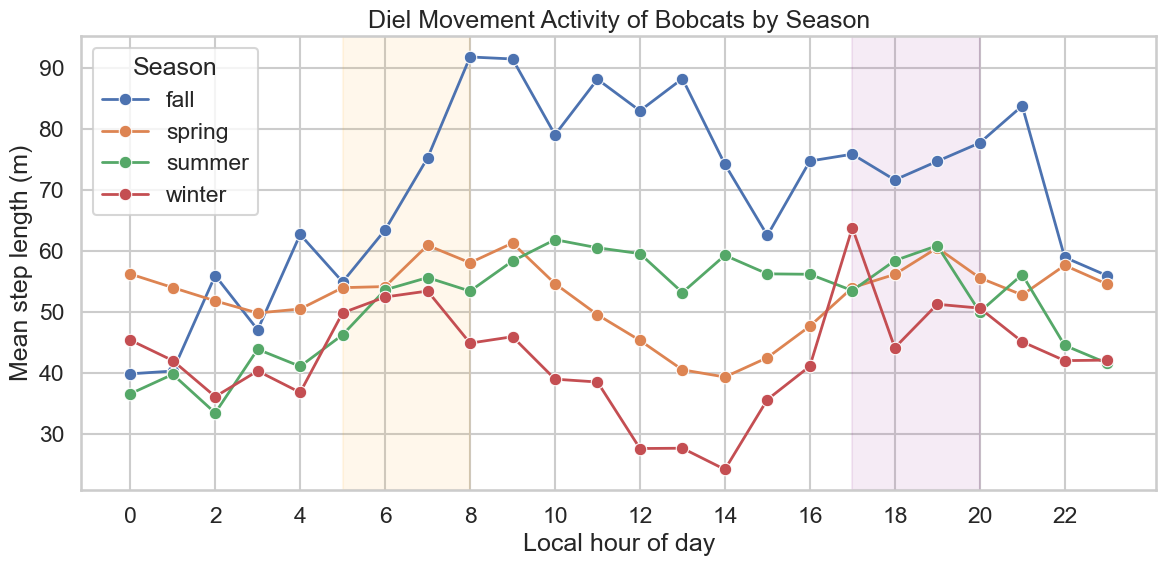

In [22]:
# Average step length for each local hour, one line per season.
# The shaded bands are dawn and dusk. If bobcats are crepuscular, the
# lines should peak there and not at midday or in the middle of the night.
hourly = (
    EDA_DF.dropna(subset=["step-meters"])
    .groupby(["season", "hour-local"])["step-meters"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly, x="hour-local", y="step-meters", hue="season", marker="o", linewidth=2
)
plt.axvspan(5, 8, alpha=0.08, color="orange")    # dawn
plt.axvspan(17, 20, alpha=0.08, color="purple")  # dusk
plt.xticks(range(0, 24, 2))
plt.xlabel("Local hour of day")
plt.ylabel("Mean step length (m)")
plt.title("Diel Movement Activity of Bobcats by Season")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Reading the chart: the x-axis is the local hour from 0 to 23, the y-axis is the average distance moved between fixes in metres (so a higher line means faster movement), and each colour is a season.

Movement bottoms out overnight, around 02:00 to 04:00 at about 45 m, then rises into two daytime humps, one in the morning near 07:00 to 10:00 (about 59 to 61 m) and another in the evening near 17:00 to 19:00 (about 56 to 60 m), with a dip between them around 14:00 to 15:00. Two bumps around a midday lull, rather than a single midday peak, is what you would expect from a crepuscular-leaning cat, though the shape is closer to cathemeral than strictly twilight-only. Fall sits highest overall (a seasonal mean near 70 m) and winter lowest (near 42 m). This is still only a description: the midday dip is shallow, so before calling the difference real we would want a proper test comparing the crepuscular, midday, and night periods.

### **Question #2: What proportion of time do _Lynx rufus_ spend in active travel versus resting (their activity budget), and how much does this vary among individuals?**


Step lengths are very right-skewed: lots of tiny steps while resting and a few long ones while travelling. A log-scaled histogram spreads them out so we can see the shape. If two humps appear, that gives us a resting/travel threshold for the activity budget.

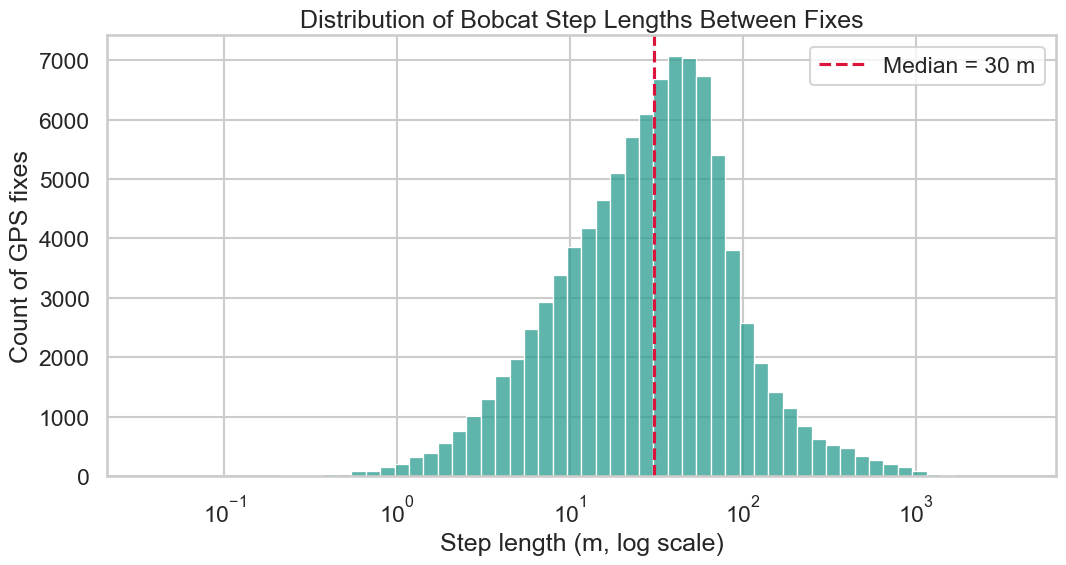

In [23]:
# Step lengths are very right-skewed: lots of tiny steps (resting) and a
# few long ones (travel). A log x-axis spreads them out. If two humps show
# up, that's the resting/travel split we can use to set a budget threshold.
steps = EDA_DF.loc[EDA_DF["step-meters"] > 0, "step-meters"]

plt.figure(figsize=(11, 6))
sns.histplot(steps, bins=60, log_scale=True, color="#2a9d8f", edgecolor="white")
plt.axvline(
    steps.median(),
    color="crimson",
    linestyle="--",
    label=f"Median = {steps.median():.0f} m",
)
plt.xlabel("Step length (m, log scale)")
plt.ylabel("Count of GPS fixes")
plt.title("Distribution of Bobcat Step Lengths Between Fixes")
plt.legend()
plt.tight_layout()
plt.show()

Reading the chart: step length is on a log x-axis, so each equal stretch is a tenfold jump (1, 10, 100, 1000 m), the y-axis counts fixes, and the dashed line is the median.

The shape is heavily right-skewed. Most steps are short, with a median around 30 m, a quarter under 13 m, and a tenth under 6 m, while a thin tail runs past 490 m for the top 1% and out to a single longest step near 3.6 km. It all forms one broad mound centred around 20 to 40 m rather than two clear peaks, and that is the catch for the activity budget: there is no natural valley to separate resting from travelling. The threshold has to come from somewhere else, like a fixed speed cutoff or a state model such as a hidden Markov model. Steps under 1 m barely appear (under 1% of the data), so at a 2-minute cadence the collar rarely catches a cat sitting completely still.

### **Question #3: Among the individuals whose records span multiple seasons, does the diel movement pattern change across seasons?**

> 

This is a heatmap of mean step length by season (rows) and local hour (columns). Each row is divided by its own maximum, so we compare the shape of the daily cycle across seasons instead of how active each season is overall. A bright band that slides left or right between rows means the timing of activity shifts with the season.

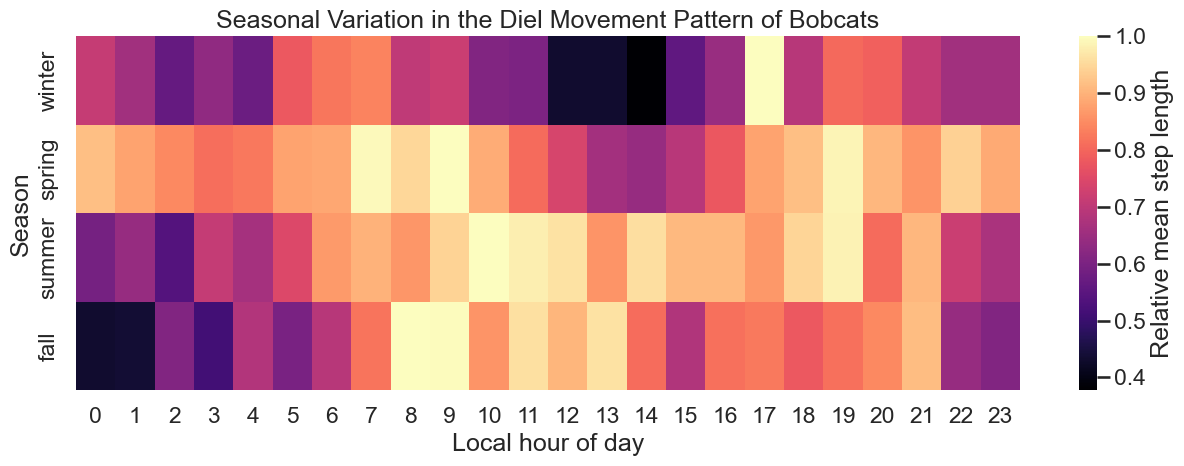

In [24]:
# Heatmap of mean step length by season (rows) and local hour (columns).
# Each row is divided by its own max, so we compare the shape of the daily
# cycle across seasons instead of how active each season is overall. Watch
# for the bright band sliding left or right between rows.
pivot = (
    EDA_DF.dropna(subset=["step-meters"])
    .pivot_table(
        index="season", columns="hour-local", values="step-meters", aggfunc="mean"
    )
    .reindex(["winter", "spring", "summer", "fall"])
)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

plt.figure(figsize=(13, 5))
sns.heatmap(pivot_norm, cmap="magma", cbar_kws={"label": "Relative mean step length"})
plt.xlabel("Local hour of day")
plt.ylabel("Season")
plt.title("Seasonal Variation in the Diel Movement Pattern of Bobcats")
plt.tight_layout()
plt.show()

Reading the chart: rows are the seasons (winter at the top, fall at the bottom), columns are the local hour from 0 to 23, and the colour is mean step length scaled within each row, so a row's brightest cell is its own busiest hour regardless of how active that season is.

The active band clearly moves. Winter peaks late, around 17:00, with a smaller bump near dawn at 06:00 to 07:00. Spring and summer lean toward the morning, brightest between 07:00 and 11:00 with a fainter echo near 19:00. Fall peaks earlier and wider in the morning, around 08:00 to 09:00. The timing roughly follows daylight: later in the short days of winter, earlier and morning-heavy in spring and summer. So the descriptive answer is yes, the daily pattern shifts by season. The catch is that only `LYRU_0001` covers all four seasons and two cats dominate the counts, so part of this could be individual identity getting mixed up with season. Splitting the heatmap by individual would settle it.